In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df=pd.read_csv('Dataset_Day7.csv')
display(df.head())
display(df.info())

,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,33.6,0.627,50,1
1,1,85,66,26.6,0.351,31,0
2,8,183,64,23.3,0.672,32,1
3,1,89,66,28.1,0.167,21,0
4,0,137,40,43.1,2.288,33,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   BMI                       768 non-null    float64
 4   DiabetesPedigreeFunction  768 non-null    float64
 5   Age                       768 non-null    int64  
 6   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(5)
memory usage: 42.1 KB


None

In [5]:
#Replace 0 with NaN
cols = ['Glucose', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction']
df[cols] = df[cols].replace(0, np.nan)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   763 non-null    float64
 2   BloodPressure             733 non-null    float64
 3   BMI                       757 non-null    float64
 4   DiabetesPedigreeFunction  768 non-null    float64
 5   Age                       768 non-null    int64  
 6   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(3)
memory usage: 42.1 KB


In [6]:
#Treating missing data
numeric_col=[]

for col in df.columns:
    if df[col].dtype.name != 'object':
        numeric_col.append(col)

print(numeric_col)

median_value = df[numeric_col].median()
print(median_value)

df = df.fillna(median_value)
df.info()

['Pregnancies', 'Glucose', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
Pregnancies                   3.0000
Glucose                     117.0000
BloodPressure                72.0000
BMI                          32.3000
DiabetesPedigreeFunction      0.3725
Age                          29.0000
Outcome                       0.0000
dtype: float64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   BMI                       768 non-null    float64
 4   DiabetesPedigreeFunction  768 non-null    float64
 5   Age                       768 non-null    int64  
 6   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(3)
m

Hence, the data is free from missing values

Question 2:

Then remove all existing outliers and get the final data for classification.

In [7]:
for col in cols:
    df[col] = (df[col] - df[col].mean()) / df[col].std()

# Outlier Detection using z-score
OutlierRows = df[
    (df["Glucose"] > 3) | (df["Glucose"] < -3) |
    (df["BloodPressure"] > 3) | (df["BloodPressure"] < -3) |
    (df["BMI"] > 3) | (df["BMI"] < -3) |
    (df["DiabetesPedigreeFunction"] > 3) | (df["DiabetesPedigreeFunction"] < -3)
]

print("% of Outlier rows in the dataset is " + str(len(OutlierRows) / len(df) * 100) + "\n")

data_OutlierFree = df.drop(OutlierRows.index, axis=0)

% of Outlier rows in the dataset is 2.734375



Question 3:

Split the data into 70% training and 30% testing data. Then, create a logistic regression model with target variable as ‘Outcome’.
a.	Print the default model performance metrics: Accuracy, Precision, Recall, F1Score & AIC

In [8]:
# Data Splitting into 70% training and 30% testing data

X = data_OutlierFree.drop("Outcome",axis=1)
y = data_OutlierFree["Outcome"]

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=203)
len(X_train),len(X_test)

# Applying Logistic Regression

from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score, precision_score, recall_score
model = LogisticRegression() 
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy is "+str(accuracy_score(y_test,y_pred)))
P = precision_score(y_test,y_pred)
print("Precision is "+str(precision_score(y_test,y_pred)))
R = recall_score(y_test,y_pred)
print("Recall is "+str(recall_score(y_test,y_pred)))
print("F1 Score is "+str((2*P*R)/(P+R)))

Accuracy is 0.76
Precision is 0.7333333333333333
Recall is 0.5365853658536586
F1 Score is 0.6197183098591549


ccuracy is 76%, but it may be unreliable

Precision is 73%, which is good

Low Recall of 53%, which means the model is missing several actual positives

F1 Score is moderate, but it shows that recall needs improvement

Question 4:

Plot a F1_score vs threshold curve. Find the threshold for which f1-score is the highest.

Optimum Threshold is [0.21310271]
Maximum F1 score:  0.7109004739336493


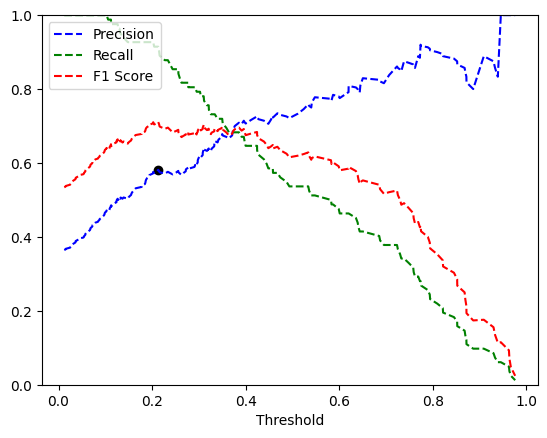

In [9]:
from sklearn.metrics import precision_recall_curve

y_probs = model.predict_proba(X_test)

prec, rec, tre = precision_recall_curve(y_test, y_probs[:,1])

def plot_prec_recall_vs_tresh(precisions, recalls, thresholds):
    f_score = (2*prec*rec)/(prec+rec)
    plt.plot(thresholds, precisions[:-1], 'b--', label='Precision')
    plt.plot(thresholds, recalls[:-1], 'g--', label = 'Recall')
    plt.plot(thresholds, f_score[:-1], 'r--', label = 'F1 Score')
    plt.xlabel('Threshold')
    plt.legend(loc='upper left')
    plt.ylim([0,1])

plot_prec_recall_vs_tresh(prec, rec, tre)
f_score = (2*prec*rec)/(prec+rec)

index = np.where(f_score == max(f_score))
thresholdOpt = tre[index]
print("Optimum Threshold is {}".format(thresholdOpt))
print("Maximum F1 score: ", max(f_score))

plt.scatter(tre[index], prec[index], marker='o', color='black', label='Best')
plt.show()

Observations:

Optimum Threshold of 0.213 gives the max F1 score of 0.711
It is the trade-off point between precision and recall
Beyond this point, even though there would be lesser positive predictions, they would more likely be correct, i.e., precision increases, recall decreases.
Plot shows better performance at threshold less than 0.5, which tells us that our data may be imbalanced.
